# Exploratory Data Analysis: Helsinki & Espoo City Bikes

This notebook performs a comprehensive EDA of the **Origin–Destination (OD) trip data** for the Helsinki and Espoo city bike system, aligned with the **multi-graph ST-GNN demand forecasting** research plan. Data covers journeys from the **2016 season** onward, with monthly CSV files under `data/trips` and station metadata in `data/stations`.

**Contents:**
1. Setup and data loading (merged or train/val/test)
2. Data overview and quality checks
3. Temporal patterns (trips over time, seasonality, weekday/hour)
4. Trip characteristics (duration, distance, speed)
5. Station usage (top origins/destinations, maps)
6. **Target variable: 3-hour inflow/outflow and zero-inflation**
7. **Spatial heterogeneity: Helsinki vs Espoo**
8. **Graph-building blocks (SD, DE, ATD, DC)**
9. **Station-level sparsity and demand graph structure**
10. **Data quality: station IDs and coverage**
11. Train / validation / test split (time-series)
12. Summary and recommendations

## 1. Setup and data loading

In [28]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

# Paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
DATA_PREPARED_DIR = DATA_DIR / "prepared"
MERGED_PATH = DATA_PREPARED_DIR / "merged" / "trips_merged.csv"
SPLITS_PATH = DATA_PREPARED_DIR / "splits"
TRAIN_PATH = SPLITS_PATH / "train" / "train.csv"
VAL_PATH = SPLITS_PATH / "validation" / "validation.csv"
TEST_PATH = SPLITS_PATH / "test" / "test.csv"

# Style
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except (OSError, AttributeError):
    plt.style.use("seaborn-whitegrid")

MAGENTA = "#6C3483"
GREEN = "#239B56"
BLUE = "#5DADE2"

In [7]:
# Load merged data (run prepare_data.py first if missing)
if MERGED_PATH.exists():
    df = pd.read_csv(MERGED_PATH, low_memory=False)
    df["departure"] = pd.to_datetime(df["departure"])
    df["return"] = pd.to_datetime(df["return"])
    print(f"Loaded merged data: {MERGED_PATH}")
else:
    # Fallback: load train + val + test if available
    parts = []
    for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
        if p.exists():
            parts.append(pd.read_csv(p, low_memory=False))
    if parts:
        df = pd.concat(parts, ignore_index=True)
        df["departure"] = pd.to_datetime(df["departure"])
        df["return"] = pd.to_datetime(df["return"])
        df = df.sort_values("departure").reset_index(drop=True)
        print(f"Loaded from train/validation/test ({len(df):,} rows)")
    else:
        raise FileNotFoundError(
            "No data found. Run: python prepare_data.py"
        )

print(f"Shape: {df.shape}")
print(f"Date range: {df['departure'].min()} to {df['departure'].max()}")

Loaded merged data: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\prepared\merged\trips_merged.csv
Shape: (21699966, 16)
Date range: 2016-05-02 09:31:00 to 2024-10-31 23:59:57


## 2. Data overview and quality

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21699966 entries, 0 to 21699965
Data columns (total 16 columns):
 #   Column               Dtype         
---  ------               -----         
 0   departure            datetime64[us]
 1   return               datetime64[us]
 2   departure_id         str           
 3   departure_name       str           
 4   return_id            str           
 5   return_name          str           
 6   distance_m           float64       
 7   duration_sec         float64       
 8   _year                int64         
 9   _month               int64         
 10  speed_kmh            float64       
 11  duration_min         float64       
 12  departure_latitude   float64       
 13  departure_longitude  float64       
 14  return_latitude      float64       
 15  return_longitude     float64       
dtypes: datetime64[us](2), float64(8), int64(2), str(4)
memory usage: 3.3 GB


In [9]:
# Standardize column names for analysis (distance_m -> distance, duration_sec -> duration)
col_map = {"distance_m": "distance", "duration_sec": "duration"}
df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})

numeric_cols = ["distance", "duration", "speed_kmh", "duration_min"]
numeric_cols = [c for c in numeric_cols if c in df.columns]
df[numeric_cols].describe()

,distance,duration,speed_kmh,duration_min
count,2.169997e+07,2.169997e+07,2.169997e+07,2.169997e+07
mean,2.359973e+03,1.003475e+03,1.615769e+01,1.672458e+01
std,1.825536e+04,9.040580e+03,1.539269e+03,1.506763e+02
min,0.000000e+00,1.000000e+00,0.000000e+00,1.666667e-02
25%,1.055000e+03,3.600000e+02,9.043137e+00,6.000000e+00
50%,1.835000e+03,6.110000e+02,1.134545e+01,1.018333e+01
75%,3.044000e+03,1.010000e+03,1.336438e+01,1.683333e+01
max,3.681399e+06,6.286982e+06,1.019462e+06,1.047830e+05


In [10]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0].sort_values(ascending=False) if missing.any() else "None")

Missing values:
None


## 3. Temporal patterns

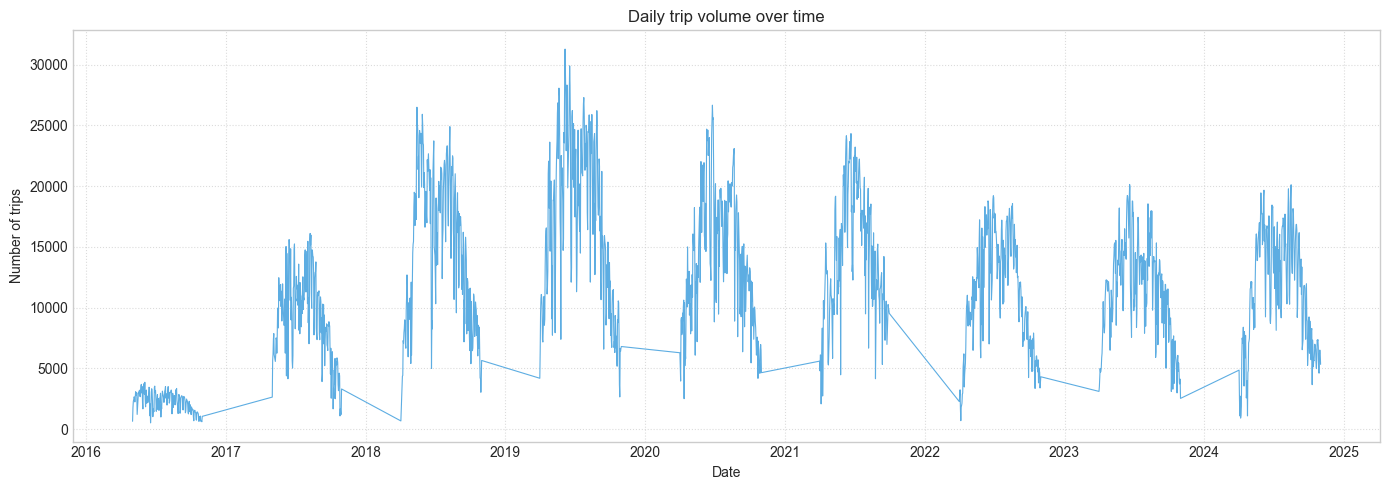

In [11]:
# Trips per day over time
daily = df.groupby(df["departure"].dt.date).size().reset_index(name="count")
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["departure"], daily["count"], color=BLUE, linewidth=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Number of trips")
ax.set_title("Daily trip volume over time")
ax.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

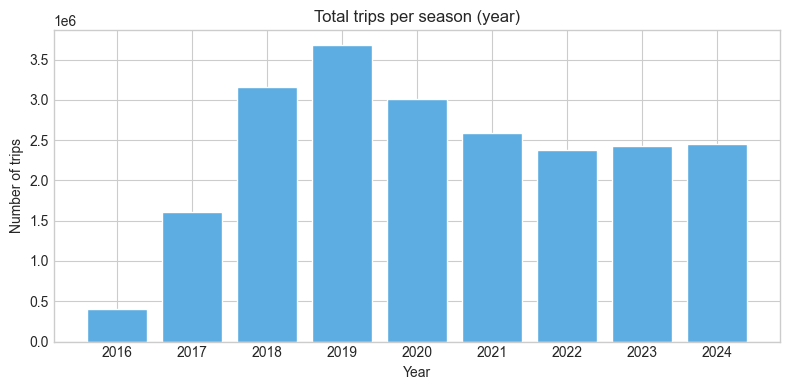

In [12]:
# Trips by year (season)
yearly = df.groupby(df["departure"].dt.year).size()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(yearly.index.astype(str), yearly.values, color=BLUE, edgecolor="white")
ax.set_xlabel("Year")
ax.set_ylabel("Number of trips")
ax.set_title("Total trips per season (year)")
plt.tight_layout()
plt.show()

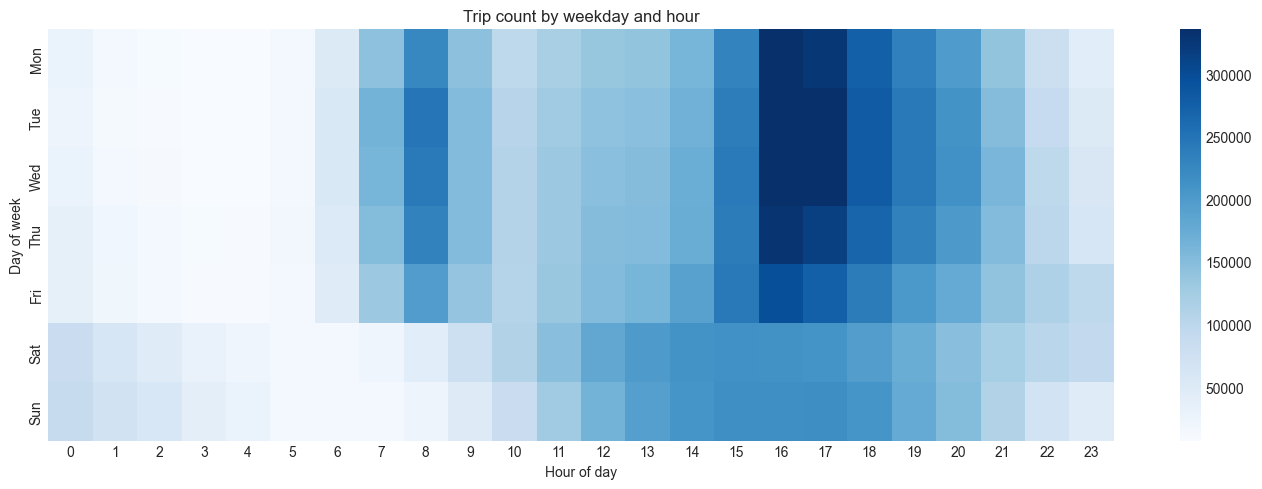

In [13]:
# Weekday × hour heatmap (activity pattern)
df["weekday"] = df["departure"].dt.dayofweek
df["hour"] = df["departure"].dt.hour
weekdays = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily_activity = df.groupby(by=["weekday", "hour"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(daily_activity, robust=True, cmap="Blues", yticklabels=weekdays, ax=ax)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
ax.set_title("Trip count by weekday and hour")
plt.tight_layout()
plt.show()

## 4. Trip characteristics: duration and distance

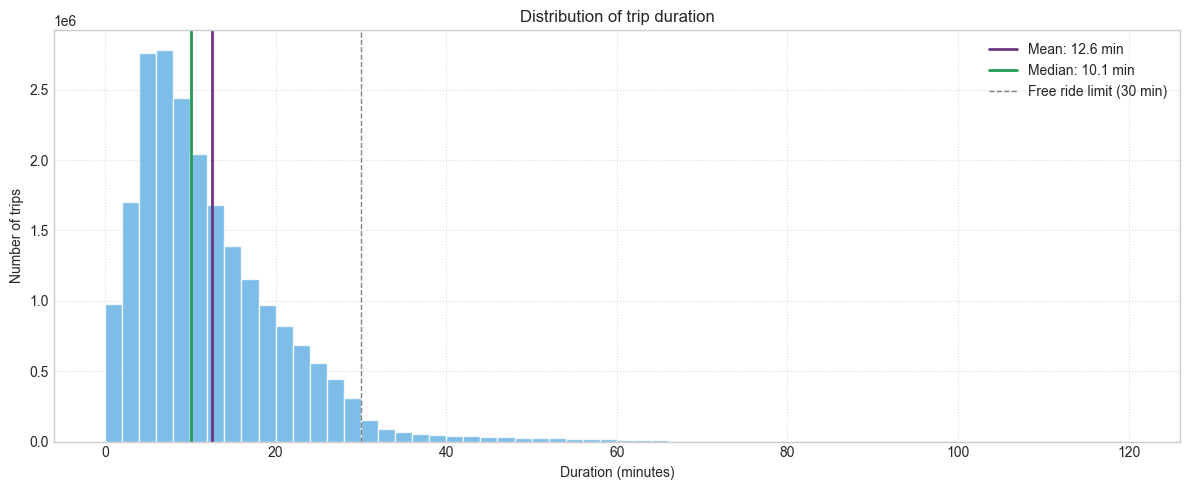

In [14]:
# Duration distribution (minutes)
duration_min = df["duration_min"] if "duration_min" in df.columns else df["duration"] / 60
duration_min = duration_min[duration_min <= 120]  # focus on 0–120 min

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(duration_min, bins=60, color=BLUE, edgecolor="white", alpha=0.8)
ax.axvline(duration_min.mean(), color=MAGENTA, linestyle="-", linewidth=2, label=f"Mean: {duration_min.mean():.1f} min")
ax.axvline(duration_min.median(), color=GREEN, linestyle="-", linewidth=2, label=f"Median: {duration_min.median():.1f} min")
ax.axvline(30, color="gray", linestyle="--", linewidth=1, label="Free ride limit (30 min)")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Number of trips")
ax.set_title("Distribution of trip duration")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

### Trips by month (seasonality within year)

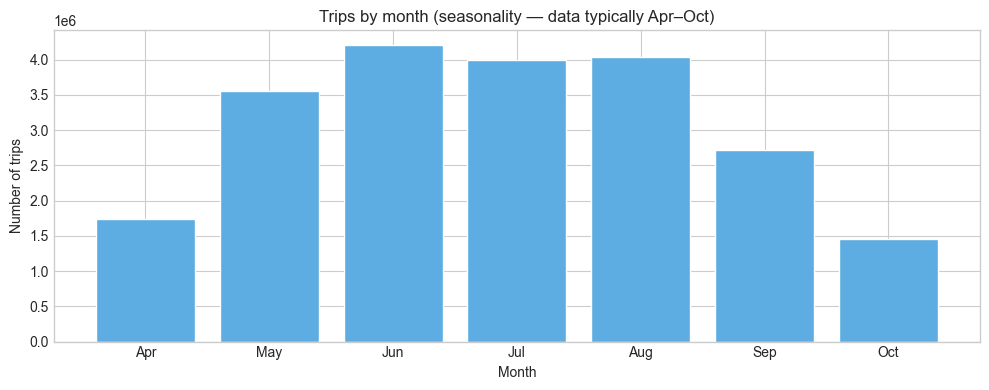

In [15]:
# Trips by month (all years combined)
df["month"] = df["departure"].dt.month
monthly = df.groupby("month").size()
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([months[i-1] for i in monthly.index], monthly.values, color=BLUE, edgecolor="white")
ax.set_xlabel("Month")
ax.set_ylabel("Number of trips")
ax.set_title("Trips by month (seasonality — data typically Apr–Oct)")
plt.tight_layout()
plt.show()

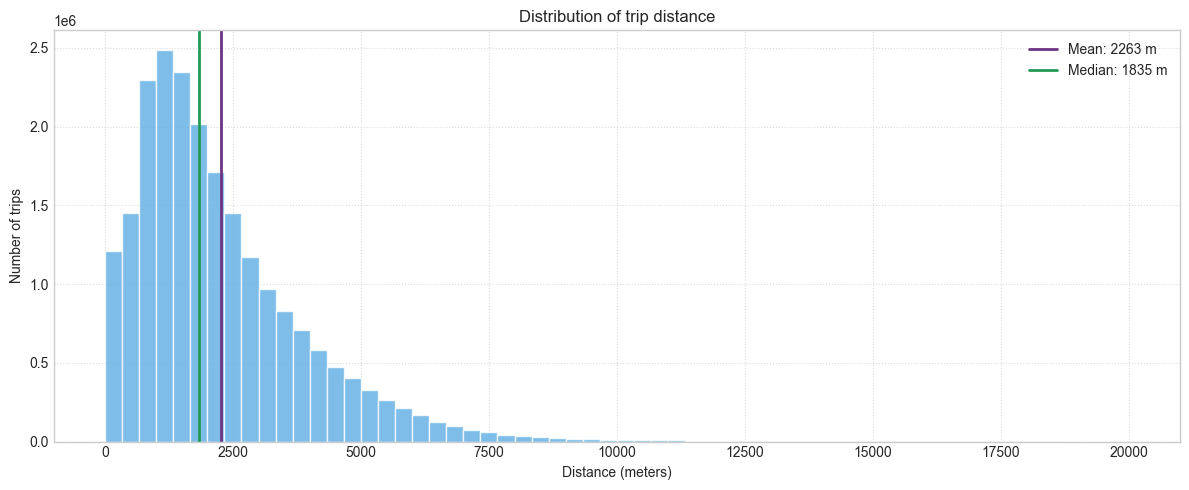

In [16]:
# Distance distribution (meters)
dist = df["distance"]
dist = dist[(dist >= 0) & (dist <= 20000)]  # 0–20 km

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(dist, bins=60, color=BLUE, edgecolor="white", alpha=0.8)
ax.axvline(dist.mean(), color=MAGENTA, linestyle="-", linewidth=2, label=f"Mean: {dist.mean():.0f} m")
ax.axvline(dist.median(), color=GREEN, linestyle="-", linewidth=2, label=f"Median: {dist.median():.0f} m")
ax.set_xlabel("Distance (meters)")
ax.set_ylabel("Number of trips")
ax.set_title("Distribution of trip distance")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

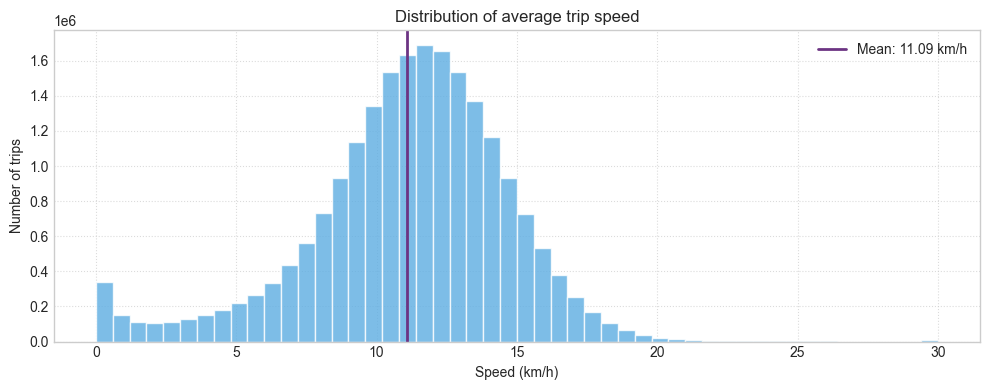

In [17]:
# Average speed (km/h) distribution
if "speed_kmh" in df.columns:
    speed = df["speed_kmh"][(df["speed_kmh"] > 0) & (df["speed_kmh"] < 30)]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(speed, bins=50, color=BLUE, edgecolor="white", alpha=0.8)
    ax.axvline(speed.mean(), color=MAGENTA, linestyle="-", linewidth=2, label=f"Mean: {speed.mean():.2f} km/h")
    ax.set_xlabel("Speed (km/h)")
    ax.set_ylabel("Number of trips")
    ax.set_title("Distribution of average trip speed")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.7)
    plt.tight_layout()
    plt.show()

## 5. Station usage

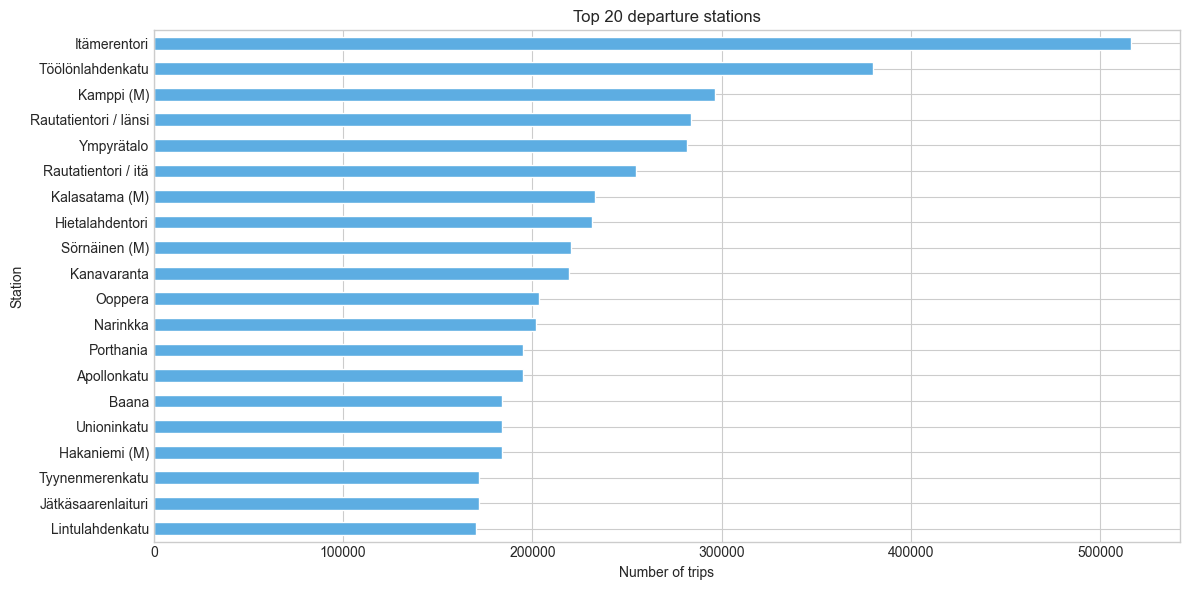

In [18]:
# Top 20 departure stations
top_dep = df["departure_name"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 6))
top_dep.plot(kind="barh", ax=ax, color=BLUE, edgecolor="white")
ax.set_xlabel("Number of trips")
ax.set_ylabel("Station")
ax.set_title("Top 20 departure stations")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

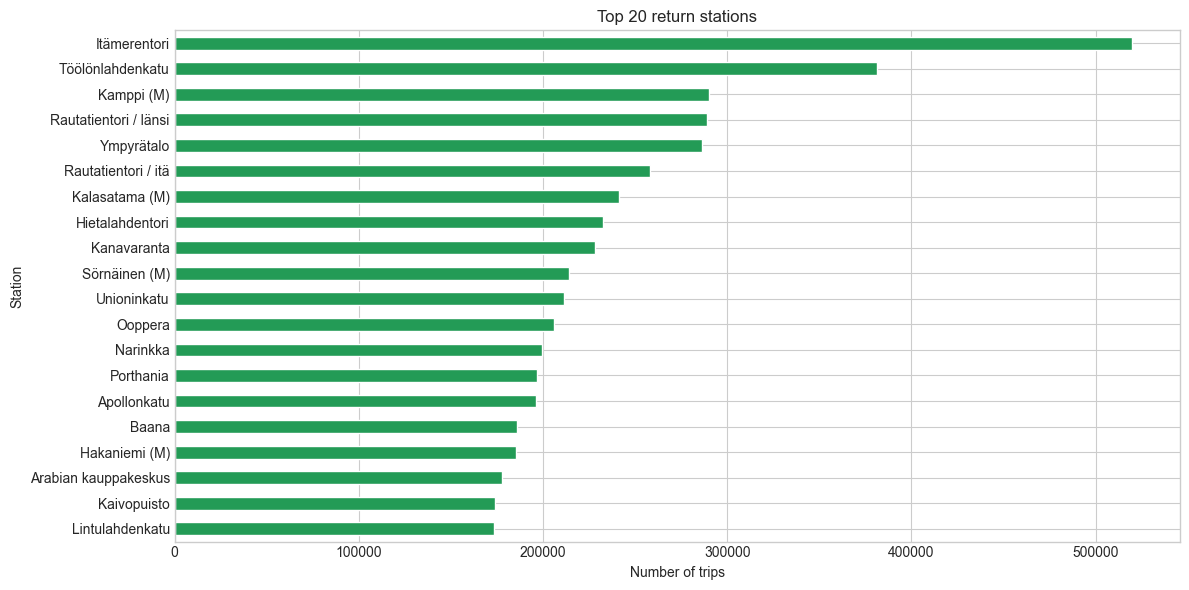

In [19]:
# Top 20 return stations
top_ret = df["return_name"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 6))
top_ret.plot(kind="barh", ax=ax, color=GREEN, edgecolor="white")
ax.set_xlabel("Number of trips")
ax.set_ylabel("Station")
ax.set_title("Top 20 return stations")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

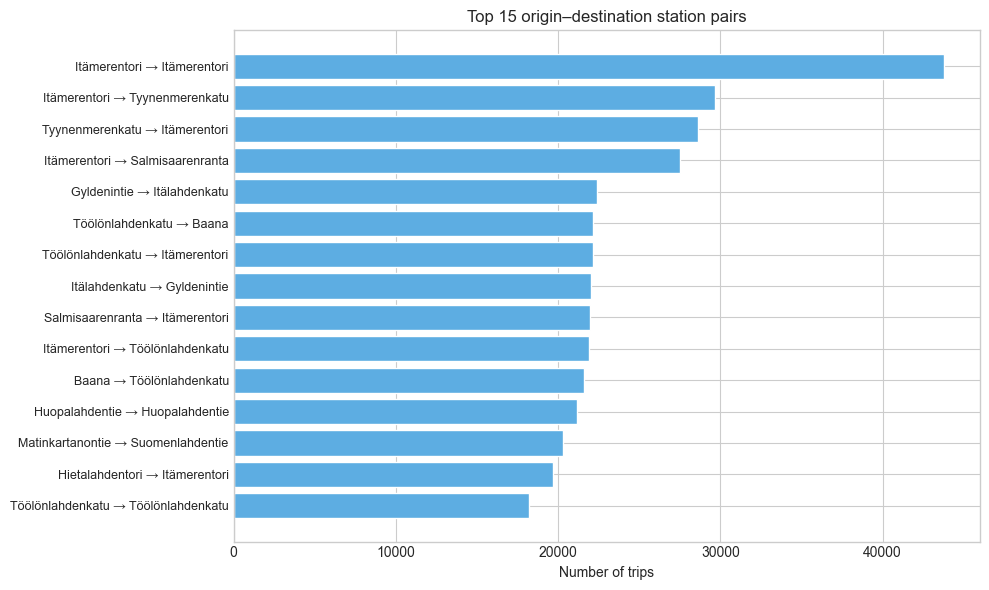

In [20]:
# Top 15 origin–destination pairs
od = df.groupby(["departure_name", "return_name"]).size().reset_index(name="trips")
od = od.sort_values("trips", ascending=False).head(15)
od["OD"] = od["departure_name"] + " → " + od["return_name"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(od)), od["trips"], color=BLUE, edgecolor="white")
ax.set_yticks(range(len(od)))
ax.set_yticklabels(od["OD"], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Number of trips")
ax.set_title("Top 15 origin–destination station pairs")
plt.tight_layout()
plt.show()

In [21]:
# Station map (Folium) — if coordinates available
try:
    import folium
    from folium import plugins

    dep_coords = df[["departure_name", "departure_latitude", "departure_longitude"]].drop_duplicates("departure_name").dropna()
    dep_counts = df["departure_name"].value_counts()
    dep_coords["count"] = dep_coords["departure_name"].map(dep_counts)
    dep_coords = dep_coords[dep_coords["count"] > 0]

    m = folium.Map(location=[60.17, 24.94], zoom_start=11, tiles="CartoDB positron")
    for _, row in dep_coords.iterrows():
        r = min(20, 5 + row["count"] / 5000)
        folium.CircleMarker(
            [row["departure_latitude"], row["departure_longitude"]],
            radius=r,
            popup=f"{row['departure_name']}: {int(row['count']):,} trips",
            color=BLUE,
            fill=True,
            fillColor=BLUE,
            fillOpacity=0.5,
        ).add_to(m)
    m.save("station_map.html")
except ImportError:
    print("Install folium for map: pip install folium")

Install folium for map: pip install folium


## 6. Target variable: hourly inflow/outflow and zero-inflation

The forecasting target is **3-hour-bucket station-level inflow and outflow** (aligned with `scripts/experiments/data.py`). Below we build illustrative series, show examples, and quantify zero-inflation (relevant for WMAPE/MASE).

In [22]:
# Build hourly inflow/outflow per station (use a sample of data for speed if full df is large)
df["hour_start"] = df["departure"].dt.floor("h")
# Outflow = departures from station; inflow = returns to station
outflow = df.groupby(["departure_name", "hour_start"]).size().reset_index(name="outflow")
outflow = outflow.rename(columns={"departure_name": "station_name"})
inflow = df.groupby(["return_name", "hour_start"]).size().reset_index(name="inflow")
inflow = inflow.rename(columns={"return_name": "station_name"})
# Merge to get all (station, hour) combinations with inflow and outflow
hourly = outflow.merge(
    inflow, on=["station_name", "hour_start"], how="outer"
).fillna(0).astype({"outflow": int, "inflow": int})
# Zero-inflation: share of (station, hour) cells that are zero
n_cells = len(hourly)
zero_inflow = (hourly["inflow"] == 0).sum()
zero_outflow = (hourly["outflow"] == 0).sum()
print(f"Hourly records: {n_cells:,} (station × hour)")
print(f"Zero inflow:  {zero_inflow:,} ({100 * zero_inflow / n_cells:.1f}%)")
print(f"Zero outflow: {zero_outflow:,} ({100 * zero_outflow / n_cells:.1f}%)")
# Per-station zero share (for stations with at least one hour)
station_zero = hourly.groupby("station_name").agg(
    zero_inflow_pct=( "inflow", lambda s: 100 * (s == 0).mean() ),
    zero_outflow_pct=("outflow", lambda s: 100 * (s == 0).mean() ),
)
print("\nPer-station zero-inflation (sample):")
print(station_zero.quantile([0.25, 0.5, 0.75]))

Hourly records: 7,978,770 (station × hour)
Zero inflow:  1,665,568 (20.9%)
Zero outflow: 1,735,538 (21.8%)

Per-station zero-inflation (sample):
      zero_inflow_pct  zero_outflow_pct
0.25        16.672440         18.087884
0.50        27.339330         28.281859
0.75        34.894614         34.849911


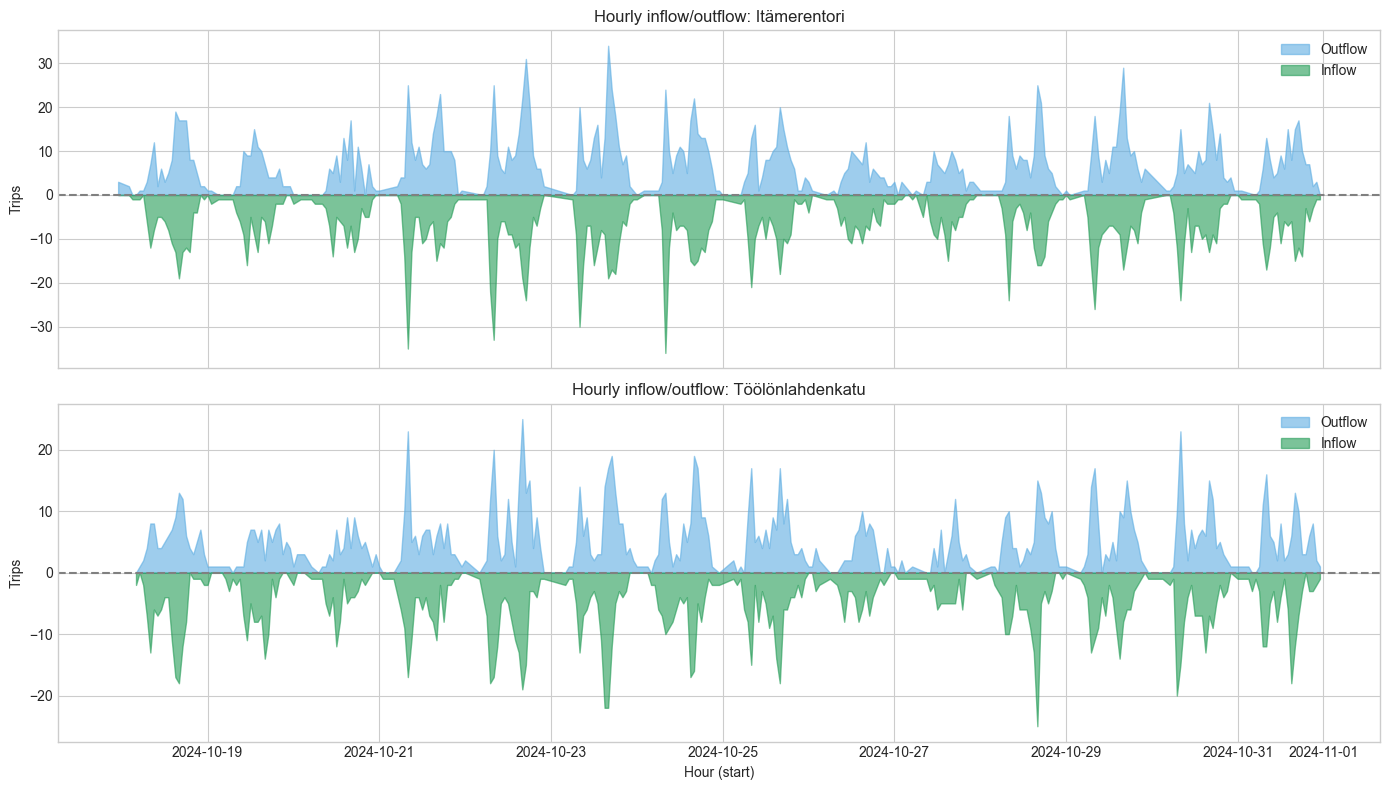

In [23]:
# Temporal aggregation sanity check: hourly inflow/outflow for 1–2 stations over ~2 weeks
top_stations = df["departure_name"].value_counts().head(2).index.tolist()
sample = hourly[hourly["station_name"].isin(top_stations)].sort_values(["station_name", "hour_start"])
# Restrict to a recent 2-week window to keep plot readable
sample = sample[sample["hour_start"] >= sample["hour_start"].max() - pd.Timedelta(days=14)]
fig, axes = plt.subplots(len(top_stations), 1, figsize=(14, 4 * len(top_stations)), sharex=True)
if len(top_stations) == 1:
    axes = [axes]
for ax, st in zip(axes, top_stations):
    sub = sample[sample["station_name"] == st]
    ax.fill_between(sub["hour_start"], sub["outflow"], alpha=0.6, label="Outflow", color=BLUE)
    ax.fill_between(sub["hour_start"], -sub["inflow"], alpha=0.6, label="Inflow", color=GREEN)
    ax.axhline(0, color="gray", linestyle="--")
    ax.set_ylabel("Trips")
    ax.legend(loc="upper right")
    ax.set_title(f"Hourly inflow/outflow: {st}")
axes[-1].set_xlabel("Hour (start)")
plt.tight_layout()
plt.show()

## 7. Spatial heterogeneity: Helsinki vs Espoo

The research plan highlights a **heterogeneous Helsinki–Espoo network** and **sparse suburban (Espoo) stations**. We map station names to city (from stations metadata) and compare volume, zero-inflation, and variance.

In [30]:
# Load station metadata for city (Kaupunki)
STATIONS_PATH = next((DATA_DIR / "primary" / "stations").glob("*.csv"), None)
if STATIONS_PATH is not None:
    stations_meta = pd.read_csv(STATIONS_PATH)
    # Map station name (Nimi or Name) to city
    name_to_city = {}
    for _, row in stations_meta.iterrows():
        for col in ("Nimi", "Name"):
            if col in stations_meta.columns and pd.notna(row[col]):
                value = str(row[col]).strip()
                name_to_city[value] = row.get("Kaupunki", row.get("Stad", "Unknown"))
                if name_to_city[value] == " ":
                    name_to_city[value] = "Helsinki"
    df["city"] = df["departure_name"].map(name_to_city)
    # Fallback: stations not in metadata (e.g. renamed) — infer from coords or leave Unknown
    df["city"] = df["city"].fillna("Unknown")
else:
    df["city"] = "Unknown"
    name_to_city = {}
print("Trips by city:")
print(df["city"].value_counts())

Trips by city:
city
Helsinki    19437727
Espoo        2262239
Name: count, dtype: int64


By city:
          n_stations  total_inflow  total_outflow  zero_inflow_pct  \
city                                                                 
Espoo            104       2262869        2262239            28.73   
Helsinki         345      19437097       19437727            18.98   

          zero_outflow_pct  
city                        
Espoo                29.45  
Helsinki             19.89  


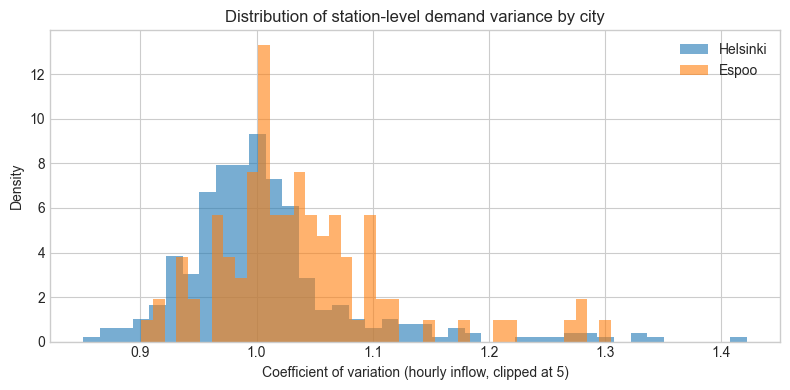

In [31]:
# Compare Helsinki vs Espoo: trips per station, zero-inflation, variance of hourly demand
hourly_city = hourly.copy()
hourly_city["city"] = hourly_city["station_name"].map(name_to_city)
hourly_city = hourly_city[hourly_city["city"].notna()]
if len(hourly_city) == 0:
    print("No city mapping. Load stations CSV with Kaupunki for Helsinki vs Espoo.")
if len(hourly_city) > 0:
    by_city = hourly_city.groupby("city").agg(
    n_stations=("station_name", "nunique"),
    total_inflow=("inflow", "sum"),
    total_outflow=("outflow", "sum"),
    zero_inflow_pct=("inflow", lambda s: 100 * (s == 0).mean()),
    zero_outflow_pct=("outflow", lambda s: 100 * (s == 0).mean()),
).round(2)
print("By city:")
print(by_city)
# Per-station variance of hourly inflow (sparse stations have high relative variance)
station_var = hourly_city.groupby(["station_name", "city"]).agg(
    mean_inflow=("inflow", "mean"),
    std_inflow=("inflow", "std"),
).fillna(0)
station_var["cv"] = np.where(station_var["mean_inflow"] > 0, station_var["std_inflow"] / station_var["mean_inflow"], np.nan)
station_var = station_var.reset_index()  # city is in index after groupby; move to column
fig, ax = plt.subplots(figsize=(8, 4))
for city in station_var["city"].dropna().unique():
    sub = station_var[station_var["city"] == city]["cv"].dropna()
    if len(sub) > 0:
        ax.hist(sub.clip(upper=5), bins=40, alpha=0.6, label=city, density=True)
ax.set_xlabel("Coefficient of variation (hourly inflow, clipped at 5)")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Distribution of station-level demand variance by city")
plt.tight_layout()
plt.show()

## 8. Graph-building blocks (SD, DE, ATD, DC)

The multi-graph pipeline uses four adjacency types: **Spatial Distance (SD)**, **Demand/flow (DE)**, **Demand Correlation (DC)**, and **Average Trip Duration (ATD)**. Here we preview the distributions of these quantities.

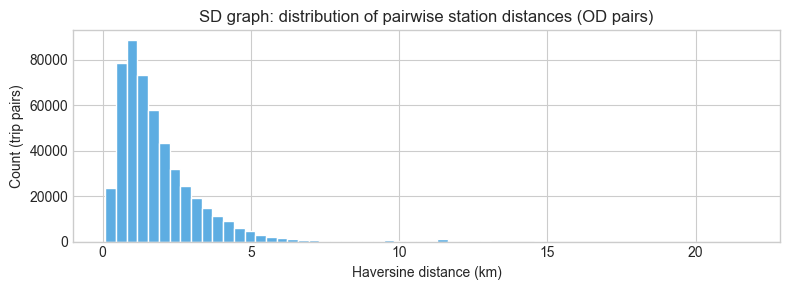

In [32]:
# SD: Haversine distance between stations (sample of OD pairs)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))
df["od_km"] = haversine(
    df["departure_latitude"], df["departure_longitude"],
    df["return_latitude"], df["return_longitude"]
)
# Sample for histogram (full df is large)
sd_sample = df["od_km"].dropna()
sd_sample = sd_sample[(sd_sample > 0) & (sd_sample < 50)]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(sd_sample.sample(min(500_000, len(sd_sample)), random_state=42), bins=60, color=BLUE, edgecolor="white")
ax.set_xlabel("Haversine distance (km)")
ax.set_ylabel("Count (trip pairs)")
ax.set_title("SD graph: distribution of pairwise station distances (OD pairs)")
plt.tight_layout()
plt.show()

DE graph: OD flow distribution
count    103638.000000
mean        209.382331
std         778.923310
min           1.000000
25%           2.000000
50%          13.000000
75%         100.000000
max       43817.000000
Name: flow, dtype: float64


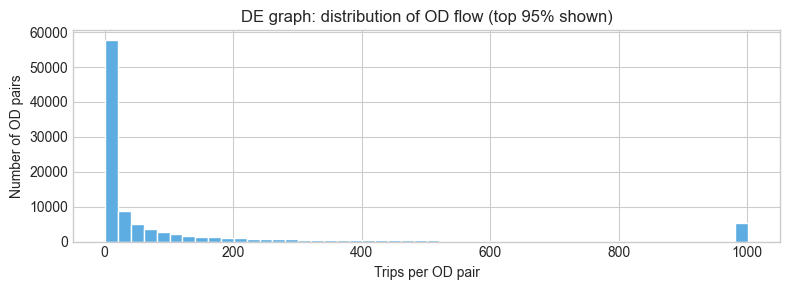

In [33]:
# DE: OD flow (trip count per origin–destination pair)
od_flow = df.groupby(["departure_name", "return_name"]).size().rename("flow")
print("DE graph: OD flow distribution")
print(od_flow.describe())
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(od_flow.clip(upper=od_flow.quantile(0.95)), bins=50, color=BLUE, edgecolor="white")
ax.set_xlabel("Trips per OD pair")
ax.set_ylabel("Number of OD pairs")
ax.set_title("DE graph: distribution of OD flow (top 95% shown)")
plt.tight_layout()
plt.show()

ATD graph: average trip duration per OD pair (seconds)
count    1.036380e+05
mean     3.104671e+03
std      3.748459e+04
min      6.000000e+00
25%      1.303783e+03
50%      1.721409e+03
75%      2.425500e+03
max      4.091873e+06
Name: avg_duration_sec, dtype: float64


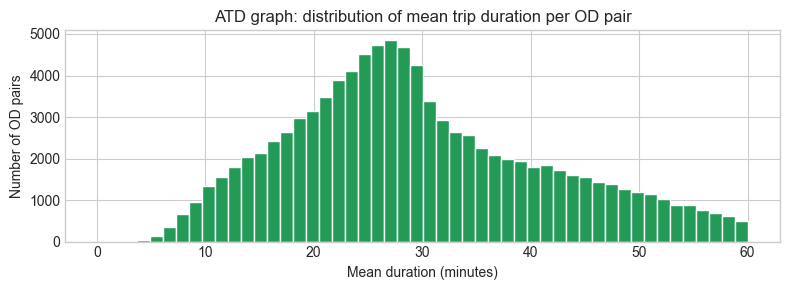

In [34]:
# ATD: Average trip duration per OD pair (seconds or minutes)
atd = df.groupby(["departure_name", "return_name"])["duration"].mean().rename("avg_duration_sec")
print("ATD graph: average trip duration per OD pair (seconds)")
print(atd.describe())
fig, ax = plt.subplots(figsize=(8, 3))
atd_min = atd / 60
atd_min = atd_min[(atd_min > 0) & (atd_min < 60)]
ax.hist(atd_min, bins=50, color=GREEN, edgecolor="white")
ax.set_xlabel("Mean duration (minutes)")
ax.set_ylabel("Number of OD pairs")
ax.set_title("ATD graph: distribution of mean trip duration per OD pair")
plt.tight_layout()
plt.show()

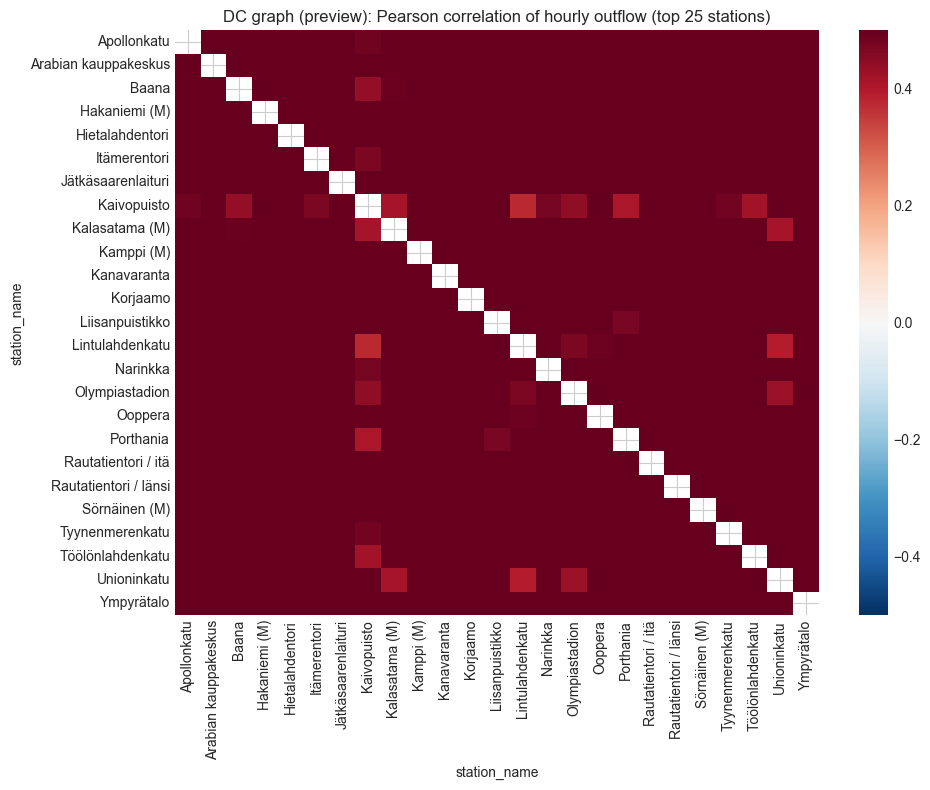

Pairwise correlations (n=300): mean=0.621, std=0.081


In [35]:
# DC: Demand correlation — Pearson correlation of hourly demand (subset of stations for speed)
top_n = 25
top_stations_dc = df["departure_name"].value_counts().head(top_n).index.tolist()
# Hourly outflow per station (pivot: hours × stations)
hours = hourly["hour_start"].unique()
hourly_pivot = hourly[hourly["station_name"].isin(top_stations_dc)].pivot_table(
    index="hour_start", columns="station_name", values="outflow", aggfunc="sum"
).fillna(0)
corr = hourly_pivot.corr()
# Mask diagonal for visualization (use mask param to avoid modifying read-only array)
mask = np.eye(len(corr), dtype=bool)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title("DC graph (preview): Pearson correlation of hourly outflow (top 25 stations)")
plt.tight_layout()
plt.show()
# Distribution of pairwise correlations (excluding diagonal)
corr_vals = corr.values[np.triu_indices_from(corr.values, k=1)]
print(f"Pairwise correlations (n={len(corr_vals)}): mean={np.nanmean(corr_vals):.3f}, std={np.nanstd(corr_vals):.3f}")

## 9. Station-level sparsity and demand graph structure

For **RQ3** (station- vs cluster-level prediction) we need to identify sparse stations and the **demand graph** structure (degree/strength) that Louvain will use.

In [36]:
# Per-station: total trips, non-zero hours, variance of hourly demand
station_stats = hourly.groupby("station_name").agg(
    total_trips=("outflow", "sum"),
    n_hours=("hour_start", "nunique"),
    zero_outflow_pct=("outflow", lambda s: 100 * (s == 0).mean()),
    mean_outflow=("outflow", "mean"),
    std_outflow=("outflow", "std"),
).fillna(0)
station_stats["cv"] = np.where(
    station_stats["mean_outflow"] > 0,
    station_stats["std_outflow"] / station_stats["mean_outflow"],
    np.nan
)
print("Station-level stats (outflow):")
print(station_stats.describe())
# Identify sparse stations (e.g. bottom decile by total trips)
station_stats = station_stats.sort_values("total_trips")
n = len(station_stats)
sparse_cutoff = station_stats["total_trips"].quantile(0.1)
sparse_stations = station_stats[station_stats["total_trips"] <= sparse_cutoff].index.tolist()
print(f"\nSparse stations (bottom 10% by total trips): {len(sparse_stations)} stations")
print("Example:", sparse_stations[:5])

Station-level stats (outflow):
         total_trips       n_hours  zero_outflow_pct  mean_outflow  \
count     449.000000    449.000000        449.000000    449.000000   
mean    48329.545657  17770.089087         26.848684      2.018208   
std     60918.404476   9884.015711          9.908309      1.562539   
min       453.000000    669.000000          7.377864      0.661661   
25%     10217.000000  10325.000000         18.087884      0.969375   
50%     21702.000000  15804.000000         28.281859      1.334372   
75%     70305.000000  26462.000000         34.849911      2.677837   
max    516315.000000  39616.000000         47.550744     13.158210   

       std_outflow          cv  
count   449.000000  449.000000  
mean      2.118192    1.039378  
std       1.724767    0.094569  
min       0.679367    0.899910  
25%       0.983070    0.982311  
50%       1.399665    1.013848  
75%       2.709504    1.068273  
max      15.191006    1.559591  

Sparse stations (bottom 10% by total tri

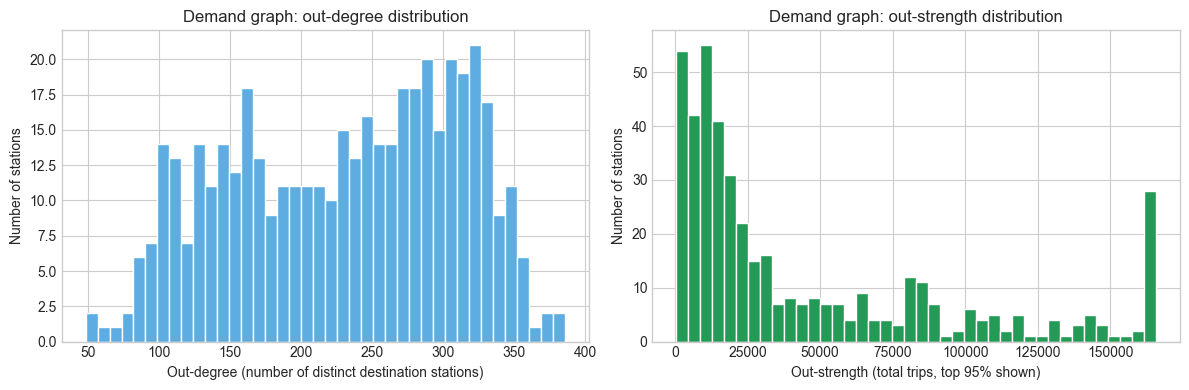

In [37]:
# Demand graph: nodes = stations, edge weight = OD flow. Degree = number of OD partners; strength = sum of flow.
# "Degree" here = number of distinct OD partners (outgoing)
out_degree = df.groupby("departure_name")["return_name"].nunique()
flow_strength_out = df.groupby("departure_name").size()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(out_degree, bins=40, color=BLUE, edgecolor="white")
axes[0].set_xlabel("Out-degree (number of distinct destination stations)")
axes[0].set_ylabel("Number of stations")
axes[0].set_title("Demand graph: out-degree distribution")
axes[1].hist(flow_strength_out.clip(upper=flow_strength_out.quantile(0.95)), bins=40, color=GREEN, edgecolor="white")
axes[1].set_xlabel("Out-strength (total trips, top 95% shown)")
axes[1].set_ylabel("Number of stations")
axes[1].set_title("Demand graph: out-strength distribution")
plt.tight_layout()
plt.show()

## 10. Data quality: station IDs and coverage

The research plan mentions **historical inconsistencies**, **missing values**, and **recycled station IDs**. We check unique stations per year and coverage.

In [38]:
# Unique stations (by name) per year — detect growth and possible ID/name changes
stations_by_year = df.groupby("_year").agg(
    n_unique_dep=("departure_name", "nunique"),
    n_unique_ret=("return_name", "nunique"),
    n_trips=("departure", "count"),
)
print("Stations and trips by year:")
print(stations_by_year)
# Stations that appear only in certain years (e.g. first/last year only)
# Vectorized: groupby once instead of filtering df per station
dep_years = df.groupby("departure_name")["_year"].unique()
ret_years = df.groupby("return_name")["_year"].unique()
all_names = set(dep_years.index) | set(ret_years.index)
station_years = {
    name: set(dep_years.get(name, [])) | set(ret_years.get(name, []))
    for name in all_names
}
only_early = [s for s, ys in station_years.items() if max(ys) <= 2017]
only_late = [s for s, ys in station_years.items() if min(ys) >= 2022]
print(f"\nStations only in early years (≤2017): {len(only_early)}")
print(f"Stations only in recent years (≥2022): {len(only_late)}")

Stations and trips by year:
       n_unique_dep  n_unique_ret  n_trips
_year                                     
2016             46            46   408095
2017            142           142  1606696
2018            243           243  3157837
2019            336           336  3677526
2020            342           342  3011954
2021            448           448  2583857
2022            448           448  2374822
2023            446           446  2425165
2024            443           443  2454014

Stations only in early years (≤2017): 0
Stations only in recent years (≥2022): 0


## 11. Train / validation / test split (time-series)

In [39]:
# Summary of split (if you ran prepare_data.py with save_splits=True)
for name, path in [("Train", TRAIN_PATH), ("Validation", VAL_PATH), ("Test", TEST_PATH)]:
    if path.exists():
        full = pd.read_csv(path, low_memory=False)
        if "departure" in full.columns:
            dep = pd.to_datetime(full["departure"])
            print(f"{name}: {len(full):,} rows, {dep.min().date()} to {dep.max().date()}")
        else:
            print(f"{name}: {len(full):,} rows")
    else:
        print(f"{name}: not found")

Train: 14,445,965 rows, 2016-05-02 to 2021-09-30
Validation: 2,374,822 rows, 2022-04-01 to 2022-10-31
Test: 4,879,179 rows, 2023-04-01 to 2024-10-31


## 12. Summary

- **Data**: OD trips 2016–2024; merged and split into train/validation/test by time.
- **Temporal**: Strong seasonality (Apr–Oct); weekday rush-hour peaks; growth over years.
- **Trips**: Duration and distance right-skewed; many trips under 30 min (free tier).
- **Stations**: A few hubs dominate; map and degree distribution show heterogeneous network.
- **Target**: Hourly inflow/outflow are zero-inflated → WMAPE/MASE appropriate.
- **Spatial**: Helsinki vs Espoo differ in volume and sparsity; Espoo more sparse.
- **Graphs**: SD, DE, ATD, DC building blocks characterized for multi-graph pipeline.
- **Next steps**: Run `prepare_data.py`; build hourly tensors and four adjacency matrices; train A3T-GCN and compare station- vs cluster-level (Louvain).